In [1]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


Using Device: cuda

Training with Lambda = 0.001
Epoch 1/10 | Loss=160867.61 | Acc=33.07% | Sparsity=0.00%
Epoch 2/10 | Loss=147391.88 | Acc=38.39% | Sparsity=0.00%
Epoch 3/10 | Loss=134204.00 | Acc=40.84% | Sparsity=0.00%
Epoch 4/10 | Loss=121460.16 | Acc=41.40% | Sparsity=0.00%
Epoch 5/10 | Loss=109316.03 | Acc=44.35% | Sparsity=0.01%
Epoch 6/10 | Loss=97909.10 | Acc=44.46% | Sparsity=0.01%
Epoch 7/10 | Loss=87341.31 | Acc=44.95% | Sparsity=0.02%
Epoch 8/10 | Loss=77683.96 | Acc=46.25% | Sparsity=0.04%
Epoch 9/10 | Loss=68963.80 | Acc=47.02% | Sparsity=0.06%
Epoch 10/10 | Loss=61173.38 | Acc=46.34% | Sparsity=0.08%

Training with Lambda = 0.01
Epoch 1/10 | Loss=1605623.92 | Acc=32.69% | Sparsity=0.00%
Epoch 2/10 | Loss=1471122.77 | Acc=37.59% | Sparsity=0.00%
Epoch 3/10 | Loss=1339297.87 | Acc=38.58% | Sparsity=0.00%
Epoch 4/10 | Loss=1211848.69 | Acc=41.75% | Sparsity=0.00%
Epoch 5/10 | Loss=1090366.53 | Acc=43.62% | Sparsity=0.01%
Epoch 6/10 | Loss=976222.40 | Acc=42.81% | Sparsity

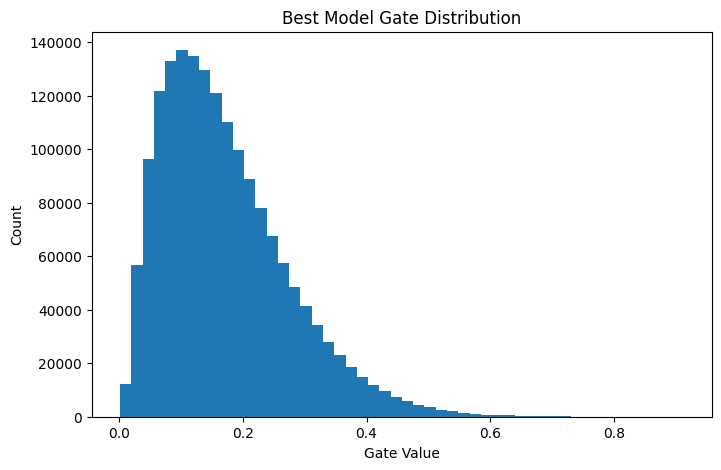


Files Saved:
results.csv
gate_histogram.png
Done ✅


In [6]:


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------------------------------------
# DEVICE
# ----------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using Device:", device)

# ----------------------------------------------------------
# HYPERPARAMETERS
# ----------------------------------------------------------
BATCH_SIZE = 256
EPOCHS = 10
LR = 0.001
LAMBDAS = [0.001, 0.01, 0.05]

# ----------------------------------------------------------
# DATASET
# ----------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ----------------------------------------------------------
# CUSTOM PRUNABLE LAYER
# ----------------------------------------------------------
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features)
        )

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return torch.matmul(x, pruned_weight.t()) + self.bias

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

# ----------------------------------------------------------
# MODEL
# ----------------------------------------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

# ----------------------------------------------------------
# LOSS FUNCTIONS
# ----------------------------------------------------------
def sparsity_loss(model):
    loss = 0
    for layer in model.modules():
        if isinstance(layer, PrunableLinear):
            loss += layer.get_gates().sum()
    return loss

# ----------------------------------------------------------
# EVALUATION
# ----------------------------------------------------------
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

# ----------------------------------------------------------
# SPARSITY %
# ----------------------------------------------------------
def get_sparsity(model):
    total = 0
    pruned = 0

    for layer in model.modules():
        if isinstance(layer, PrunableLinear):
            gates = layer.get_gates()

            total += gates.numel()
            pruned += (gates < 0.01).sum().item()

    return 100 * pruned / total

# ----------------------------------------------------------
# TRAIN FUNCTION
# ----------------------------------------------------------
def train_model(lambda_val):

    print("\n===================================")
    print("Training with Lambda =", lambda_val)
    print("===================================")

    model = Net().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS):

        model.train()
        running_loss = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            cls_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = cls_loss + lambda_val * sp_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        acc = evaluate(model)
        sp = get_sparsity(model)

        print(f"Epoch {epoch+1}/{EPOCHS} | Loss={running_loss:.2f} | Acc={acc:.2f}% | Sparsity={sp:.2f}%")

    return model, acc, sp

# ----------------------------------------------------------
# MAIN LOOP
# ----------------------------------------------------------
results = []
best_model = None
best_acc = 0

for lam in LAMBDAS:

    model, acc, sp = train_model(lam)

    results.append({
        "Lambda": lam,
        "Accuracy (%)": round(acc, 2),
        "Sparsity (%)": round(sp, 2)
    })

    if acc > best_acc:
        best_acc = acc
        best_model = model

# ----------------------------------------------------------
# RESULTS TABLE
# ----------------------------------------------------------
df = pd.DataFrame(results)

print("\nFINAL RESULTS")
print(df)

# ----------------------------------------------------------
# SAVE CSV
# ----------------------------------------------------------
df.to_csv("results.csv", index=False)

# ----------------------------------------------------------
# HISTOGRAM OF BEST MODEL
# ----------------------------------------------------------
all_gates = []

for layer in best_model.modules():
    if isinstance(layer, PrunableLinear):
        gates = layer.get_gates().detach().cpu().numpy().flatten()
        all_gates.extend(gates)

plt.figure(figsize=(8,5))
plt.hist(all_gates, bins=50)
plt.title("Best Model Gate Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Count")
plt.savefig("gate_histogram.png")
plt.show()

print("\nFiles Saved:")
print("results.csv")
print("gate_histogram.png")
print("Done ✅")